# Week 5 Lab Notebook #3: The Training Process
## Teaching Neural Networks to Learn

### Learning Objectives
By the end of this notebook, you will:
- Understand the complete training loop
- Break down Week 4's demo code step by step
- Implement training from scratch
- Monitor training progress
- Understand loss functions and optimizers

---

In [1]:
# Import everything we need
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)

print("Ready to train neural networks!")

Ready to train neural networks!


## Part 1: The Big Picture

### How Neural Networks Learn:
1. **Forward Pass**: Input → Network → Prediction
2. **Calculate Loss**: How wrong was our prediction?
3. **Backward Pass**: Calculate gradients (how to improve)
4. **Update Weights**: Adjust parameters to reduce loss
5. **Repeat**: Do this many times with different data

Let's see this in action with a simple example first!

## Part 2: Learning a Simple Pattern

Before jumping into MNIST, let's train a tiny network to learn a simple pattern: y = 2x + 1

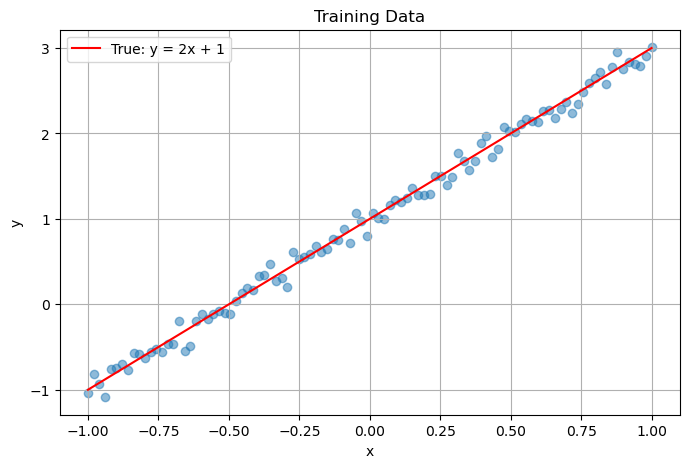

In [26]:
# Step 1: Create simple training data
# We want the network to learn y = 2x + 1

# Generate training data
x_train = torch.linspace(-1, 1, 100).reshape(-1, 1)  # 100 points from -1 to 1
y_train = 2 * x_train + 1  # True relationship

# Add some noise to make it more realistic
y_train = y_train + 0.1 * torch.randn_like(y_train)

# Visualize our data
plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, alpha=0.5)
plt.plot(x_train, 2 * x_train + 1, 'r-', label='True: y = 2x + 1')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Training Data')
plt.grid(True)
plt.show()

Initial parameters:
0.weight: -0.355
0.bias: 0.994


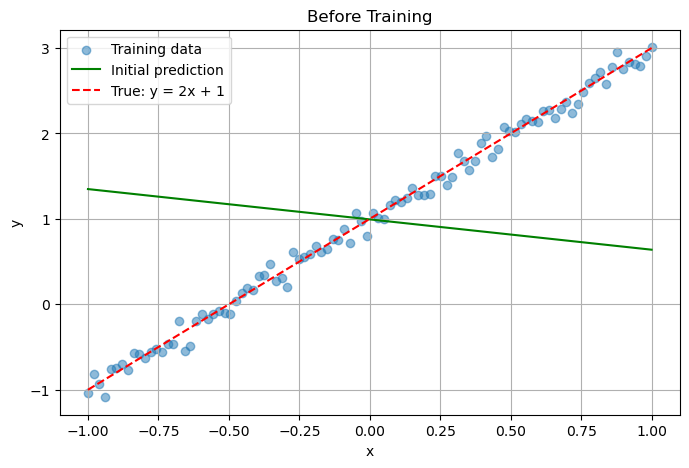

In [108]:
# Step 2: Create a simple neural network
# Just one linear layer (like linear regression)
simple_model = nn.Sequential(
    nn.Linear(1, 1)  # 1 input → 1 output
)

# Look at initial random parameters
print("Initial parameters:")
for name, param in simple_model.named_parameters():
    print(f"{name}: {param.data.item():.3f}")

# Make initial prediction
with torch.no_grad():
    initial_pred = simple_model(x_train)
    
plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, alpha=0.5, label='Training data')
plt.plot(x_train, initial_pred, 'g-', label='Initial prediction')
plt.plot(x_train, 2 * x_train + 1, 'r--', label='True: y = 2x + 1')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Before Training')
plt.grid(True)
plt.show()

## Part 3: The Training Loop - Step by Step

Now let's train our network to learn the pattern!

In [41]:
# Step 3: Set up training components

# Loss function: Measures how wrong our predictions are
criterion = nn.MSELoss()  # Mean Squared Error for regression

# Optimizer: Updates weights based on gradients
optimizer = optim.SGD(simple_model.parameters(), lr=0.01)  # lr = learning rate

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: MSELoss()
Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


Epoch 20/100, Loss: 0.0086
Epoch 40/100, Loss: 0.0086
Epoch 60/100, Loss: 0.0086
Epoch 80/100, Loss: 0.0086
Epoch 100/100, Loss: 0.0086


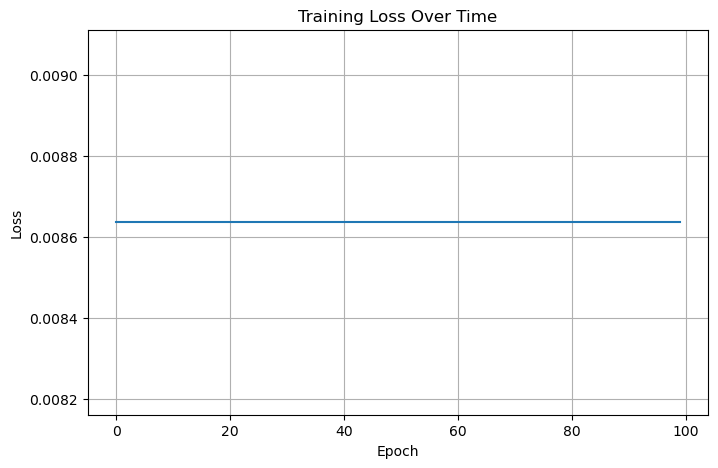


 Training complete!


In [104]:
# Step 4: Training loop
num_epochs = 100
losses = []

for epoch in range(num_epochs):
    # 1. Forward pass: compute predictions
    predictions = simple_model(x_train)
    
    # 2. Calculate loss
    loss = criterion(predictions, y_train)
    
    # 3. Backward pass: compute gradients
    optimizer.zero_grad()  # Clear old gradients
    loss.backward()        # Calculate new gradients
    
    # 4. Update weights
    optimizer.step()       # Apply gradients to weights
    
    # Store loss for plotting
    losses.append(loss.item())
    
    # Print progress every 20 epochs
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")

# Plot training progress
plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.grid(True)
plt.show()

print("\n Training complete!")

Learned parameters:
0.weight: 1.990
0.bias: 0.989

Should be close to:
Weight: 2.000 (slope)
Bias: 1.000 (intercept)


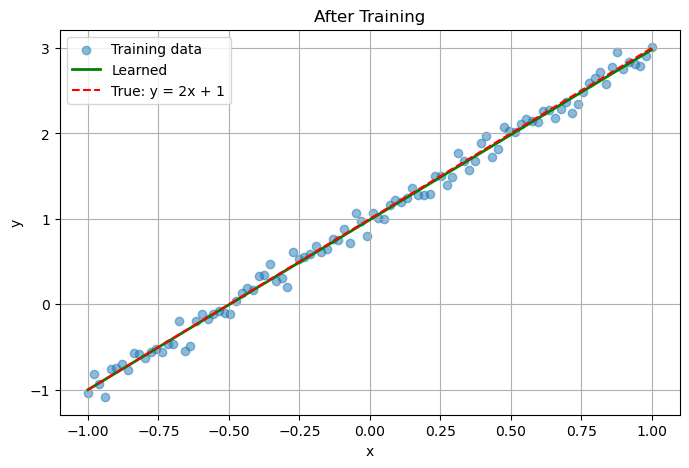

In [63]:
# Step 5: Check what the network learned
print("Learned parameters:")
for name, param in simple_model.named_parameters():
    print(f"{name}: {param.data.item():.3f}")

print("\nShould be close to:")
print("Weight: 2.000 (slope)")
print("Bias: 1.000 (intercept)")

# Visualize final predictions
with torch.no_grad():
    final_pred = simple_model(x_train)
    
plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, alpha=0.5, label='Training data')
plt.plot(x_train, final_pred, 'g-', linewidth=2, label='Learned')
plt.plot(x_train, 2 * x_train + 1, 'r--', label='True: y = 2x + 1')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('After Training')
plt.grid(True)
plt.show()

### 🎯 Your Turn: Exercise 3.1
Modify the training to:
1. Use a learning rate of 0.1 (instead of 0.01)
2. Train for only 50 epochs
3. Observe: Does it learn faster? Better? Worse?

epoch 6/50, loss: 1.0593
epoch 12/50, loss: 0.4262
epoch 18/50, loss: 0.1856
epoch 24/50, loss: 0.0845
epoch 30/50, loss: 0.0412
epoch 36/50, loss: 0.0226
epoch 42/50, loss: 0.0146
epoch 48/50, loss: 0.0112


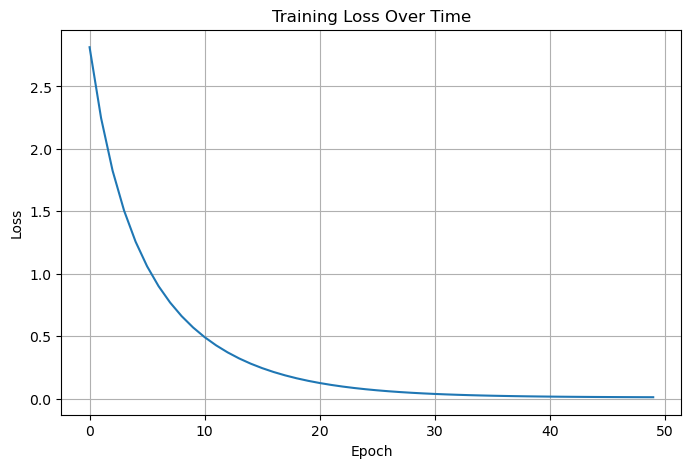

In [101]:
# Your code here:
# Reset the model
simple_model_v2 = nn.Sequential(
    nn.Linear(1, 1)
    )

# Set up training with new learning rate
criterion = nn.MSELoss()
optimiser = optim.SGD(simple_model_v2.parameters(), lr=0.1)

# Training loop
num_epochs = 50
losses_v2 = []

# Don't forget to store losses!

for epoch in range(num_epochs):
    #forward pass
    prediction = simple_model_v2(x_train)
    #calculate loss
    loss = criterion(prediction, y_train)
    #backward pass / compute gradient
    optimiser.zero_grad() #clear old gradients
    loss.backward() #calculate new gradients
    #update weights
    optimiser.step() #apply gradients to weights
    #store loss for plotting - visual
    losses_v2.append(loss.item())
    #print every 6 epochs
    if (epoch + 1) % 6 == 0:
        print(f"epoch {epoch + 1}/{num_epochs}, loss: {loss.item():.4f}")

# Plot and compare
plt.figure(figsize=(8, 5))
plt.plot(losses_v2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.grid(True)
plt.show()

---

## Part 4: Understanding MNIST Data Loading

Now let's look at how Week 4's notebook handled MNIST data:

In [85]:
# Download and prepare MNIST dataset
transform = transforms.ToTensor()  # Convert images to tensors

# Training dataset
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

# Test dataset
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=transform
)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# Look at one sample
image, label = train_dataset[0]
print(f"\nImage shape: {image.shape}")
print(f"Label: {label}")

Training samples: 60000
Test samples: 10000

Image shape: torch.Size([1, 28, 28])
Label: 5


### DataLoader: Batching for Efficiency

Training on one image at a time is slow. **DataLoader** groups images into batches:

Batch of images shape: torch.Size([64, 1, 28, 28])
Batch of labels shape: torch.Size([64])

This means: 64 images, each 28×28 pixels


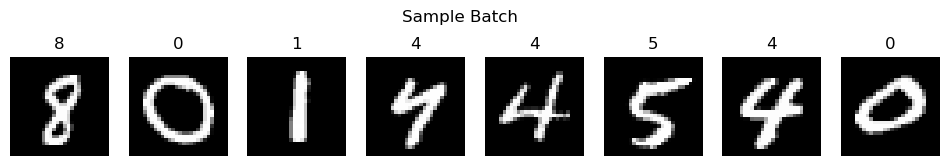

In [88]:
# Create DataLoaders
batch_size = 64

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True  # Randomize order each epoch
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False  # Keep test order consistent
)

# Look at one batch
images, labels = next(iter(train_loader))
print(f"Batch of images shape: {images.shape}")
print(f"Batch of labels shape: {labels.shape}")
print(f"\nThis means: {images.shape[0]} images, each {images.shape[2]}×{images.shape[3]} pixels")

# Visualize a few images from the batch
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    axes[i].imshow(images[i].squeeze(), cmap='gray')
    axes[i].set_title(f'{labels[i].item()}')
    axes[i].axis('off')
plt.suptitle('Sample Batch')
plt.show()

---

## Part 5: Training on MNIST

Now let's put it all together and train a real network on MNIST!

In [89]:
# Build the same model from Week 4
class MNISTNet(nn.Module):
    def __init__(self):
        super(MNISTNet, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    
    def forward(self, x):
        return self.model(x)

# Create model instance
model = MNISTNet()
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

MNISTNet(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)

Total parameters: 109,386


In [90]:
# Set up training
criterion = nn.CrossEntropyLoss()  # For classification
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam optimizer

# Training settings
num_epochs = 2  # Just 2 for demonstration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f"Training on: {device}")
print("Ready to train!")

Training on: cpu
Ready to train!


In [91]:
# THE MAIN TRAINING LOOP
# This is what Week 4 was doing behind the scenes!

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    # Training mode
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Loop through all batches
    for batch_idx, (images, labels) in enumerate(train_loader):
        # Move data to device
        images, labels = images.to(device), labels.to(device)
        
        # 1. Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # 2. Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # 3. Update weights
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Print progress every 100 batches
        if batch_idx % 100 == 0:
            print(f'Epoch {epoch+1}, Batch {batch_idx}/{len(train_loader)}, '
                  f'Loss: {loss.item():.4f}')
    
    # Calculate epoch statistics
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    print(f'\nEpoch [{epoch+1}/{num_epochs}] - '
          f'Loss: {epoch_loss:.4f}, '
          f'Accuracy: {epoch_acc:.2f}%\n')

print(" Training complete!")

Epoch 1, Batch 0/938, Loss: 2.2971
Epoch 1, Batch 100/938, Loss: 0.3994
Epoch 1, Batch 200/938, Loss: 0.3870
Epoch 1, Batch 300/938, Loss: 0.3186
Epoch 1, Batch 400/938, Loss: 0.2741
Epoch 1, Batch 500/938, Loss: 0.2549
Epoch 1, Batch 600/938, Loss: 0.1390
Epoch 1, Batch 700/938, Loss: 0.1756
Epoch 1, Batch 800/938, Loss: 0.2159
Epoch 1, Batch 900/938, Loss: 0.0656

Epoch [1/2] - Loss: 0.3417, Accuracy: 90.26%

Epoch 2, Batch 0/938, Loss: 0.0518
Epoch 2, Batch 100/938, Loss: 0.1152
Epoch 2, Batch 200/938, Loss: 0.0526
Epoch 2, Batch 300/938, Loss: 0.1222
Epoch 2, Batch 400/938, Loss: 0.1533
Epoch 2, Batch 500/938, Loss: 0.1098
Epoch 2, Batch 600/938, Loss: 0.1635
Epoch 2, Batch 700/938, Loss: 0.0569
Epoch 2, Batch 800/938, Loss: 0.1134
Epoch 2, Batch 900/938, Loss: 0.1198

Epoch [2/2] - Loss: 0.1361, Accuracy: 95.92%

 Training complete!


## Part 6: Evaluating the Model

Training accuracy doesn't tell the whole story. Let's test on unseen data:

In [94]:
# Evaluation mode
model.eval()
correct = 0
total = 0

# No gradients needed for evaluation
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f'Test Accuracy: {test_accuracy:.2f}%')
print(f'Correctly classified: {correct}/{total}')

Test Accuracy: 96.56%
Correctly classified: 9656/10000


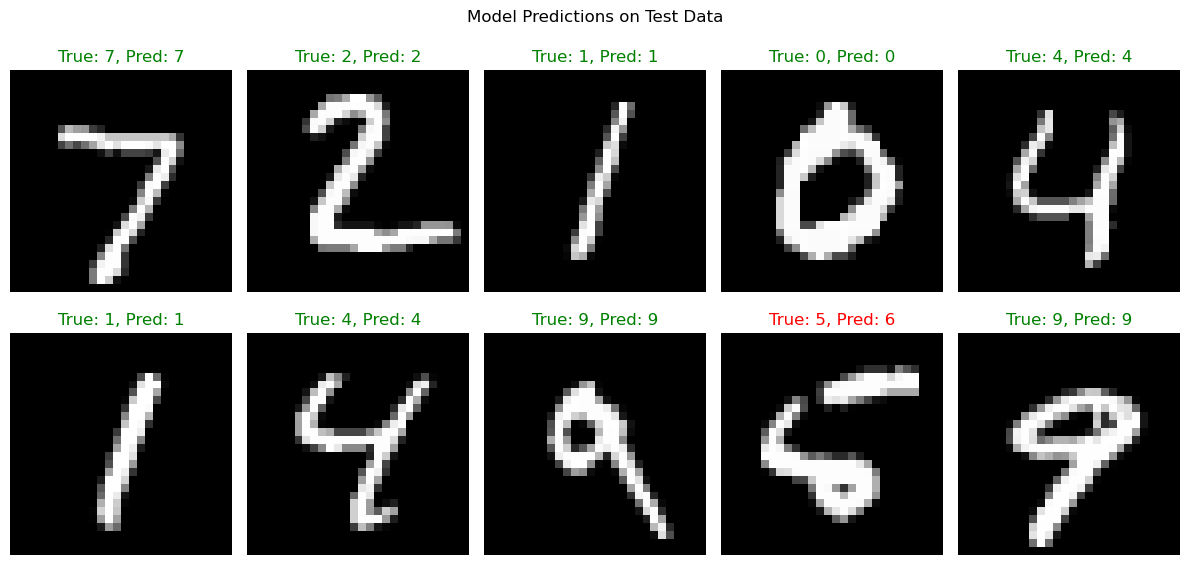

In [95]:
# Visualize some predictions
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

# Show first 10 predictions
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(images[i].cpu().squeeze(), cmap='gray')
    axes[i].set_title(f'True: {labels[i].cpu()}, Pred: {predicted[i].cpu()}')
    axes[i].axis('off')
    
    # Color code: green if correct, red if wrong
    if labels[i] == predicted[i]:
        axes[i].set_title(f'True: {labels[i].cpu()}, Pred: {predicted[i].cpu()}', color='green')
    else:
        axes[i].set_title(f'True: {labels[i].cpu()}, Pred: {predicted[i].cpu()}', color='red')

plt.suptitle('Model Predictions on Test Data')
plt.tight_layout()
plt.show()

### 🎯 Your Turn: Exercise 6.1
Find and visualize:
1. One example where the model is very confident and correct
2. One example where the model is wrong
3. Look at the confidence scores (probabilities) for each

best correct example: tensor(56)
wrong: tensor(8)


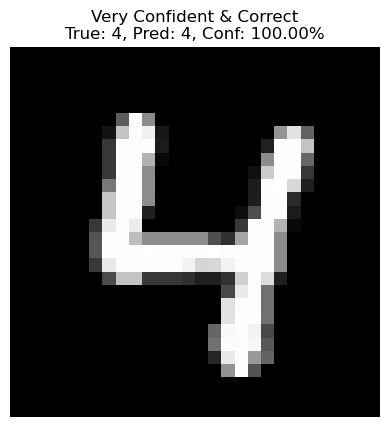

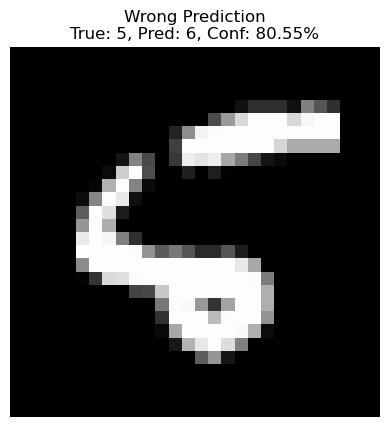

In [ ]:
# Your code here:
# Hint: Use torch.softmax(outputs, dim=1) to get probabilities
# Hint: Use torch.max(probabilities) to get confidence

# Get a batch of test images
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images) #raw digits
    probabilities = torch.softmax(outputs, dim=1) #convert to probabilities
    confidences, predicted = torch.max(probabilities, dim=1) #get max probability AND prediction / argmax = index not value

# Find examples
correct_example = (predicted == labels) #shows that they are right
best_correct_index = torch.argmax(confidences * correct_example.float()) #if * by right ones, wrong ones all = 0
#argmax gets index of max value / best prediction

wrong_example = (predicted != labels) 
wrong_index = torch.argmax(confidences * wrong_example.float()) #same, all correct confidences = 0

print("best correct example:",best_correct_index) 
print("wrong:", wrong_index)

# YOUR CODE to find and visualize the requested examples
def show_example(idx, title): 
    plt.imshow(images[idx].cpu().squeeze(), cmap='gray')
    plt.title(f"{title}\nTrue: {labels[idx].item()}, Pred: {predicted[idx].item()}, Conf: {confidences[idx].item():.2%}")
    plt.axis('off')
    plt.show()

#using function for best prediction
show_example(best_correct_index, "Very Confident & Correct")

#function for incorrect
show_example(wrong_index, "Wrong Prediction")



---

## Part 7: Saving and Loading Models

After training, we want to save our model for later use:

In [125]:
# Save the model
torch.save(model.state_dict(), 'my_mnist_model.pth')
print("Model saved!")

# Load the model
# First create a new model instance
new_model = MNISTNet()
new_model.load_state_dict(torch.load('my_mnist_model.pth'))
new_model.eval()
print("Model loaded!")

# Verify it works
test_image, test_label = test_dataset[0]
test_image = test_image.unsqueeze(0)  # Add batch dimension

with torch.no_grad():
    output = new_model(test_image)
    _, predicted = torch.max(output, 1)
    
print(f"\nTest prediction: {predicted.item()}")
print(f"True label: {test_label}")

Model saved!
Model loaded!

Test prediction: 7
True label: 7


/var/folders/tm/46k17psd507b0n0q943qxth40000gn/T/ipykernel_17164/2495877241.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  new_model.load_state_dict(torch.load('my_mnis

---

## Summary

### What You've Learned:
✓ **The training loop**: Forward → Loss → Backward → Update  
✓ **Loss functions**: MSE for regression, CrossEntropy for classification  
✓ **Optimizers**: SGD and Adam update weights based on gradients  
✓ **DataLoaders**: Efficiently batch and shuffle data  
✓ **Evaluation**: Always test on unseen data  
✓ **Saving models**: Preserve your trained networks  

### The Training Recipe:
```python
for epoch in range(num_epochs):
    for batch in dataloader:
        # 1. Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        # 2. Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # 3. Update weights
        optimizer.step()
```

### What's Next:
You now have all the pieces to train your own neural networks! In Assignment 2, you'll experiment with different architectures and hyperparameters.

---

## In-class Assignment 2/4 Part 3/3 (Part of Your Assessment Hand-In)
## Training Process Experiment

**Your Task:** Understand how training parameters affect learning by running a controlled experiment.

### Instructions:
1. Use the provided baseline model
2. Change ONE training parameter
3. Compare results with the baseline
4. Explain what you observed and why you think it happened

In [183]:
# BASELINE MODEL (Don't modify this)
baseline_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

# BASELINE TRAINING PARAMETERS (Don't modify these)
baseline_lr = 0.001
baseline_epochs = 3
baseline_optimizer_type = 'Adam'

print("Baseline Configuration:")
print(f"- Learning Rate: {baseline_lr}")
print(f"- Epochs: {baseline_epochs}")
print(f"- Optimizer: {baseline_optimizer_type}")
print("\nNow create your experimental version...")

Baseline Configuration:
- Learning Rate: 0.001
- Epochs: 3
- Optimizer: Adam

Now create your experimental version...


### Your Experiment

Choose ONE of the following changes:
- **Option A**: Change learning rate (try 0.01 or 0.0001)
- **Option B**: Change number of epochs (try 1 or 10)
- **Option C**: Change optimizer (try SGD instead of Adam)

In [184]:
# YOUR EXPERIMENTAL MODEL (same architecture as baseline)
experimental_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

# YOUR EXPERIMENTAL PARAMETERS (change ONE of these)
experimental_lr = 0.001         # Your choice
experimental_epochs = 23     # Your choice
experimental_optimizer = optim.Adam  # Your choice: optim.Adam or optim.SGD

# State your change
print("My Experiment:")
print("I changed: Epochs")
print("From: 3 to: 23")

My Experiment:
I changed: Epochs
From: 3 to: 23


In [185]:
# TRAINING FUNCTION (Provided - use for both models)
def train_and_evaluate(model, learning_rate, epochs, optimizer_class):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optimizer_class(model.parameters(), lr=learning_rate)
    
    # Storage for results
    train_losses = []
    
    # Training
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            
            # Quick training - only 100 batches per epoch for speed
            if i >= 100:
                break
        
        avg_loss = epoch_loss / (i + 1)
        train_losses.append(avg_loss)
        print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}')
    
    # Evaluation
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            if total >= 1000:  # Test on 1000 samples
                break
    
    accuracy = 100 * correct / total
    return train_losses, accuracy

In [186]:
# RUN BASELINE
print("Training Baseline Model...")
baseline_losses, baseline_accuracy = train_and_evaluate(
    baseline_model, baseline_lr, baseline_epochs, optim.Adam
)
print(f"\nBaseline Accuracy: {baseline_accuracy:.2f}%\n")

# RUN YOUR EXPERIMENT
print("Training Experimental Model...")
experimental_losses, experimental_accuracy = train_and_evaluate(
    experimental_model, experimental_lr, experimental_epochs, experimental_optimizer
)
print(f"\nExperimental Accuracy: {experimental_accuracy:.2f}%")

Training Baseline Model...
Epoch 1/3, Loss: 1.0465
Epoch 2/3, Loss: 0.3896
Epoch 3/3, Loss: 0.3057

Baseline Accuracy: 91.02%

Training Experimental Model...
Epoch 1/23, Loss: 1.0654
Epoch 2/23, Loss: 0.3806
Epoch 3/23, Loss: 0.3212
Epoch 4/23, Loss: 0.2737
Epoch 5/23, Loss: 0.2419
Epoch 6/23, Loss: 0.2326
Epoch 7/23, Loss: 0.1997
Epoch 8/23, Loss: 0.1917
Epoch 9/23, Loss: 0.1842
Epoch 10/23, Loss: 0.1642
Epoch 11/23, Loss: 0.1567
Epoch 12/23, Loss: 0.1626
Epoch 13/23, Loss: 0.1360
Epoch 14/23, Loss: 0.1402
Epoch 15/23, Loss: 0.1212
Epoch 16/23, Loss: 0.1136
Epoch 17/23, Loss: 0.1231
Epoch 18/23, Loss: 0.1112
Epoch 19/23, Loss: 0.1183
Epoch 20/23, Loss: 0.0997
Epoch 21/23, Loss: 0.0970
Epoch 22/23, Loss: 0.1074
Epoch 23/23, Loss: 0.1003

Experimental Accuracy: 96.68%


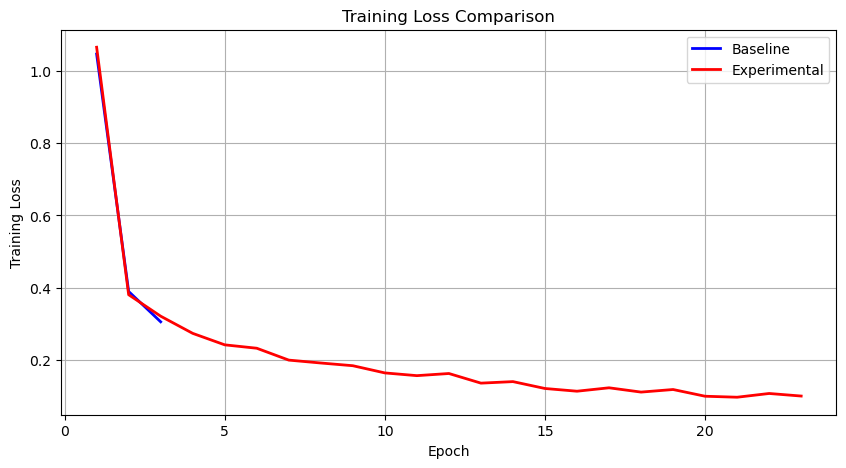


=== RESULTS SUMMARY ===
Baseline - Final Loss: 0.3057, Accuracy: 91.02%
Experimental - Final Loss: 0.1003, Accuracy: 96.68%

Difference in accuracy: +5.66%


In [187]:
# VISUALIZE THE COMPARISON
plt.figure(figsize=(10, 5))

# Plot training curves
epochs_baseline = range(1, len(baseline_losses) + 1)
epochs_experimental = range(1, len(experimental_losses) + 1)

plt.plot(epochs_baseline, baseline_losses, 'b-', label='Baseline', linewidth=2)
plt.plot(epochs_experimental, experimental_losses, 'r-', label='Experimental', linewidth=2)

plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True)
plt.show()

# Print summary
print("\n=== RESULTS SUMMARY ===")
print(f"Baseline - Final Loss: {baseline_losses[-1]:.4f}, Accuracy: {baseline_accuracy:.2f}%")
print(f"Experimental - Final Loss: {experimental_losses[-1]:.4f}, Accuracy: {experimental_accuracy:.2f}%")
print(f"\nDifference in accuracy: {experimental_accuracy - baseline_accuracy:+.2f}%")

### 📝 YOUR ANALYSIS (Required for Assignment 2)

Answer these questions based on your experiment:

1. **What parameter did you change and how?**
   - I changed: [YOUR ANSWER]
   - From: [VALUE] to: [VALUE]

2. **What happened to the training loss?**
   - [Describe: Did it decrease faster/slower? Was it more/less stable?]

3. **What happened to the final accuracy?**
   - [Better/worse by how much?]

4. **WHY do you think this happened?**
   - [Your explanation - think about what the parameter controls]

5. **What would you try next?**
   - [Based on these results, what experiment would you run next?]

In [ ]:
# Write your analysis here as comments or in a string
my_analysis = """
1. I changed: epoch from 3 to 23

2. Training loss: 0.1003, it decreased a lot slower but overall decreased more than the original

3. Final accuracy: 96.68% , it got better by +5.66% 

4. Why this happened: the training data was able to pass thorugh the neural network, forward and backward, 23 times instead of 3 so it
                        it could adjust the weights and minimise the loss to learn the patterns better  

5. Next experiment: i would try to change the other parameters, like the learning rate, to see if the loss would decrease quicker
"""

print(my_analysis)


1. I changed: epoch from 3 to 23

2. Training loss: 0.1003, it decreased a lot slower and less, but it 

3. Final accuracy: 96.68% , it got better by +5.66% 

4. Why this happened: it was able to run the training data thorugh the neural network, forward and backward, 23 times instead of 3

5. Next experiment: i would try to change the other parameters to see if it would decrease quicker



---

### Submission Checklist for Assignment 2 - Part 3:
- [ ] Ran baseline model
- [ ] Changed ONE parameter for experimental model
- [ ] Both models trained successfully
- [ ] Completed the analysis questions
- [ ] Saved this notebook with all outputs

Great work! You've just conducted your first machine learning experiment! 